In [45]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 연관분석 라이브러리
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import itertools

In [46]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [47]:
df = pd.read_csv("../df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [48]:
df = df.dropna()

# 전체 기간(3년) + PCA 기반 CV 가중치 — 5점 체계, 4등급

## Step 1: RFM 지표 계산 (전체 기간)

In [49]:
# =============================================
# Step 1: 전체 기간 RFM 지표 계산 (PCA 버전)
# =============================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df['OrderDT'] = pd.to_datetime(df['OrderDT'])
snapshot_date = pd.Timestamp('2025-12-30')
# 전체 데이터 기반 RFM 집계
rfm_pca = df.groupby('idUser').agg(
    Recency=('OrderDT', lambda x: (snapshot_date - x.max()).days),
    Frequency=('idOrder', 'nunique'),
    Monetary=('Price', 'sum')
).reset_index()

print(f"=== 전체 기간 RFM 기술통계량 (PCA 버전) ===")
print(f"분석 대상 고객 수: {len(rfm_pca):,}명")
print(f"분석 기간: {df['OrderDT'].min().date()} ~ {df['OrderDT'].max().date()}\n")
print(rfm_pca[['Recency', 'Frequency', 'Monetary']].describe().round(2))

=== 전체 기간 RFM 기술통계량 (PCA 버전) ===
분석 대상 고객 수: 3,000명
분석 기간: 2023-01-02 ~ 2025-12-29

       Recency  Frequency    Monetary
count  3000.00    3000.00     3000.00
mean     16.30      57.01  4388287.82
std      18.16      12.99   994365.45
min       0.00       9.00   792360.00
25%       4.00      49.00  3739295.00
50%      11.00      60.00  4459500.00
75%      21.00      66.00  5081795.00
max     193.00      90.00  7432080.00


## Step 2: CV 측정 및 PCA 가중치 도출

In [50]:
# =============================================
# Step 2: CV 측정 및 PCA 기반 가중치 산출
# =============================================

# 2-1. CV(변동계수) 확인
cv_r = rfm_pca['Recency'].std() / rfm_pca['Recency'].mean()
cv_f = rfm_pca['Frequency'].std() / rfm_pca['Frequency'].mean()
cv_m = rfm_pca['Monetary'].std() / rfm_pca['Monetary'].mean()

print("=== 변동계수(CV) ===")
print(f"Recency  CV: {cv_r:.4f}")
print(f"Frequency CV: {cv_f:.4f}")
print(f"Monetary  CV: {cv_m:.4f}")

# 2-2. 표준화
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_pca[['Recency', 'Frequency', 'Monetary']])

# 2-3. PCA 수행 (3개 주성분 모두 추출)
pca = PCA(n_components=3)
pca.fit(rfm_scaled)

print(f"\n=== PCA 결과 ===")
print(f"설명 분산 비율: {pca.explained_variance_ratio_.round(4)}")
print(f"누적 설명 분산: {pca.explained_variance_ratio_.cumsum().round(4)}")
print(f"\n주성분 로딩(Components):")
loading_df = pd.DataFrame(
    pca.components_,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=[f'PC{i+1}' for i in range(3)]
)
print(loading_df.round(4))

# 2-4. 가중치 산출: 각 변수별로 |로딩| × 설명분산비율 합산
weights_raw = np.zeros(3)
for i in range(3):
    weights_raw += np.abs(pca.components_[i]) * pca.explained_variance_ratio_[i]

# 정규화 (합 = 1)
weights_pca = weights_raw / weights_raw.sum()

w_r_pca, w_f_pca, w_m_pca = weights_pca

print(f"\n=== PCA 기반 가중치 (정규화) ===")
print(f"Recency  가중치: {w_r_pca:.4f}")
print(f"Frequency 가중치: {w_f_pca:.4f}")
print(f"Monetary  가중치: {w_m_pca:.4f}")
print(f"합계: {weights_pca.sum():.4f}")

=== 변동계수(CV) ===
Recency  CV: 1.1144
Frequency CV: 0.2279
Monetary  CV: 0.2266

=== PCA 결과 ===
설명 분산 비율: [0.6499 0.3288 0.0213]
누적 설명 분산: [0.6499 0.9787 1.    ]

주성분 로딩(Components):
     Recency  Frequency  Monetary
PC1  -0.1192     0.7016    0.7025
PC2   0.9928     0.0913    0.0773
PC3   0.0099    -0.7066    0.7075

=== PCA 기반 가중치 (정규화) ===
Recency  가중치: 0.2882
Frequency 가중치: 0.3573
Monetary  가중치: 0.3544
합계: 1.0000


## Step 3: RFM 점수화 (1~5점, 5분위수 기반)

In [51]:
# =============================================
# Step 3: RFM 점수 부여 (1~5점, 5분위수 기반)
# =============================================

# R: 낮을수록(최근) 좋으므로 역순
rfm_pca['R_score'] = pd.qcut(rfm_pca['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)

# F: 높을수록 좋으므로 정순
rfm_pca['F_score'] = pd.qcut(rfm_pca['Frequency'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

# M: 높을수록 좋으므로 정순
rfm_pca['M_score'] = pd.qcut(rfm_pca['Monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

print("=== RFM 점수 분포 (1~5점) ===")
for col in ['R_score', 'F_score', 'M_score']:
    print(f"\n{col}:")
    print(rfm_pca[col].value_counts().sort_index())

=== RFM 점수 분포 (1~5점) ===

R_score:
R_score
1    545
2    648
3    561
4    645
5    601
Name: count, dtype: int64

F_score:
F_score
1    645
2    586
3    605
4    620
5    544
Name: count, dtype: int64

M_score:
M_score
1    600
2    600
3    601
4    599
5    600
Name: count, dtype: int64


## Step 4: 복합점수 계산 및 등급 부여

In [52]:
# =============================================
# Step 4: PCA 가중치 적용 및 4등급 분류 (방법 C: 백분위수 기반)
# =============================================

# 4-1. 각 변수를 백분위수로 변환 (0~100)
rfm_pca['R_percentile'] = rfm_pca['Recency'].rank(pct=True) * 100
rfm_pca['F_percentile'] = rfm_pca['Frequency'].rank(pct=True) * 100
rfm_pca['M_percentile'] = rfm_pca['Monetary'].rank(pct=True) * 100

# ⚠️ Recency는 역방향 (낮을수록 좋음)
rfm_pca['R_percentile'] = 100 - rfm_pca['R_percentile']

# 4-2. PCA 가중치를 적용한 종합 점수 (0~100)
rfm_pca['composite_score'] = (
    rfm_pca['R_percentile'] * w_r_pca +
    rfm_pca['F_percentile'] * w_f_pca +
    rfm_pca['M_percentile'] * w_m_pca
)

# 4-3. 고정 기준값으로 등급 분류
def assign_grade_percentile(score):
    """
    고정 기준값으로 등급 할당
    - VIP (80~100): 상위 20% 최우수 고객
    - Gold (60~79): 상위 20~40% 우수 고객
    - Silver (40~59): 중간 40~60% 일반 고객
    - Bronze (0~39): 하위 40% 잠재 고객
    """
    if score >= 80:
        return 'VIP'
    elif score >= 60:
        return 'Gold'
    elif score >= 40:
        return 'Silver'
    else:
        return 'Bronze'

rfm_pca['Grade'] = rfm_pca['composite_score'].apply(assign_grade_percentile)

# 4-4. 결과 출력
print(f"=== PCA 기반 가중치 ===")
print(f"Recency  가중치: {w_r_pca:.4f}")
print(f"Frequency 가중치: {w_f_pca:.4f}")
print(f"Monetary  가중치: {w_m_pca:.4f}")

print(f"\n=== 종합 점수 통계 ===")
print(f"점수 범위: {rfm_pca['composite_score'].min():.2f} ~ {rfm_pca['composite_score'].max():.2f}")
print(f"평균: {rfm_pca['composite_score'].mean():.2f}")
print(f"중앙값: {rfm_pca['composite_score'].median():.2f}")
print(f"표준편차: {rfm_pca['composite_score'].std():.2f}")

print(f"\n=== 등급별 고객 수 (실제 분포) ===")
grade_counts = rfm_pca['Grade'].value_counts().sort_index()
grade_pct = rfm_pca['Grade'].value_counts(normalize=True).sort_index() * 100
grade_summary = pd.DataFrame({
    '고객 수': grade_counts,
    '비율 (%)': grade_pct.round(2)
})
print(grade_summary)

print(f"\n=== 등급별 점수 범위 ===")
score_range = rfm_pca.groupby('Grade', observed=True)['composite_score'].agg(['min', 'max', 'mean'])
print(score_range.round(2))

print(f"\n=== 등급별 RFM 평균 ===")
rfm_by_grade = rfm_pca.groupby('Grade', observed=True)[['Recency', 'Frequency', 'Monetary']].mean()
print(rfm_by_grade.round(2))

print(f"\n=== 등급별 백분위수 평균 ===")
percentile_by_grade = rfm_pca.groupby('Grade', observed=True)[['R_percentile', 'F_percentile', 'M_percentile']].mean()
print(percentile_by_grade.round(2))

# 4-5. 등급별 상세 분석
print(f"\n=== 등급별 상세 분석 ===")
for grade in ['VIP', 'Gold', 'Silver', 'Bronze']:
    grade_data = rfm_pca[rfm_pca['Grade'] == grade]
    if len(grade_data) > 0:
        print(f"\n📊 {grade} 등급:")
        print(f"  고객 수: {len(grade_data)}명 ({len(grade_data)/len(rfm_pca)*100:.1f}%)")
        print(f"  종합점수: {grade_data['composite_score'].min():.1f}~{grade_data['composite_score'].max():.1f}")
        print(f"  Recency (최근방문일): {grade_data['Recency'].mean():.1f}일 (낮을수록 좋음)")
        print(f"  Frequency (구매빈도): {grade_data['Frequency'].mean():.1f}회")
        print(f"  Monetary (구매금액): {grade_data['Monetary'].mean():.0f}원")

=== PCA 기반 가중치 ===
Recency  가중치: 0.2882
Frequency 가중치: 0.3573
Monetary  가중치: 0.3544

=== 종합 점수 통계 ===
점수 범위: 0.27 ~ 98.69
평균: 50.01
중앙값: 49.63
표준편차: 22.41

=== 등급별 고객 수 (실제 분포) ===
        고객 수  비율 (%)
Grade               
Bronze  1082   36.07
Gold     759   25.30
Silver   852   28.40
VIP      307   10.23

=== 등급별 점수 범위 ===
          min    max   mean
Grade                      
Bronze   0.27  39.99  25.81
Gold    60.01  79.98  69.64
Silver  40.02  59.96  49.89
VIP     80.09  98.69  87.07

=== 등급별 RFM 평균 ===
        Recency  Frequency    Monetary
Grade                                 
Bronze    22.59      43.93  3407814.15
Gold      11.88      67.00  5156352.19
Silver    16.83      58.84  4457355.80
VIP        3.57      73.32  5753322.77

=== 등급별 백분위수 평균 ===
        R_percentile  F_percentile  M_percentile
Grade                                           
Bronze         38.75         20.61         20.54
Gold           56.00         75.18         75.13
Silver         48.26         50.51 

## Step 5: 시각화

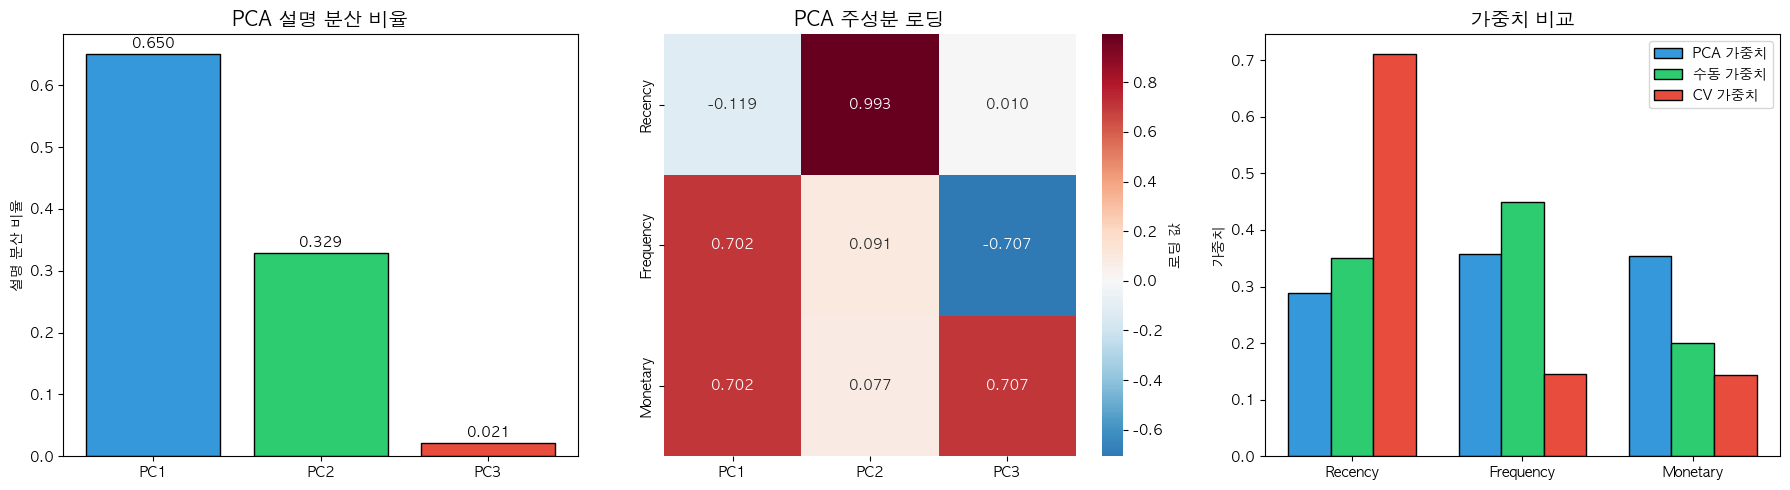

In [53]:
# =============================================
# Step 5-1: 시각화 - PCA 설명 분산 및 가중치 비교
# =============================================

# CV 기반 가중치 (Cell 7에서 산출된 CV 값 기반)
_cv_r, _cv_f, _cv_m = 1.1144, 0.2279, 0.2266
_total_cv = _cv_r + _cv_f + _cv_m
w_r = _cv_r / _total_cv  # ≈ 0.7103
w_f = _cv_f / _total_cv  # ≈ 0.1452
w_m = _cv_m / _total_cv  # ≈ 0.1444

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) PCA 설명 분산 비율
pcs = [f'PC{i+1}' for i in range(3)]
axes[0].bar(pcs, pca.explained_variance_ratio_, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('PCA 설명 분산 비율', fontsize=14, fontweight='bold')
axes[0].set_ylabel('설명 분산 비율')
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# (2) PCA 로딩 히트맵
sns.heatmap(loading_df.T, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            ax=axes[1], cbar_kws={'label': '로딩 값'})
axes[1].set_title('PCA 주성분 로딩', fontsize=14, fontweight='bold')

# (3) 가중치 비교 (PCA vs 수동 vs CV)
labels = ['Recency', 'Frequency', 'Monetary']
x = np.arange(len(labels))
width = 0.25

axes[2].bar(x - width, [w_r_pca, w_f_pca, w_m_pca], width, label='PCA 가중치', color='#3498db', edgecolor='black')
axes[2].bar(x, [0.35, 0.45, 0.20], width, label='수동 가중치', color='#2ecc71', edgecolor='black')
axes[2].bar(x + width, [w_r, w_f, w_m], width, label='CV 가중치', color='#e74c3c', edgecolor='black')
axes[2].set_title('가중치 비교', fontsize=14, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel('가중치')
axes[2].legend()

plt.tight_layout()
plt.show()

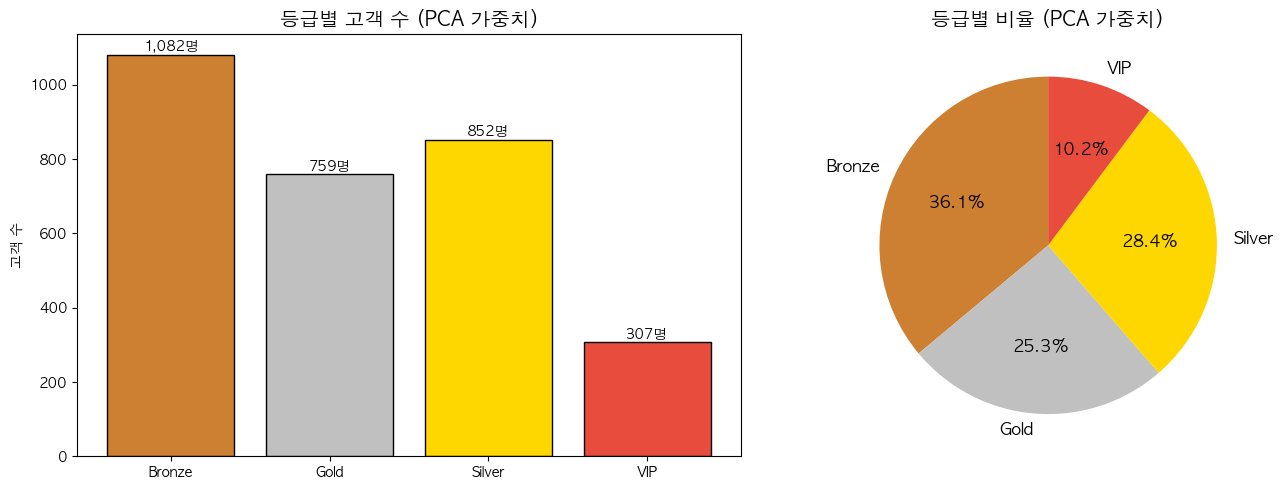

In [54]:
# =============================================
# Step 5-2: 시각화 - 등급별 고객 수 분포
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_counts_pca = rfm_pca['Grade'].value_counts().sort_index()
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']

axes[0].bar(grade_counts_pca.index, grade_counts_pca.values, color=colors, edgecolor='black')
axes[0].set_title('등급별 고객 수 (PCA 가중치)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('고객 수')
for i, v in enumerate(grade_counts_pca.values):
    axes[0].text(i, v + 10, f'{v:,}명', ha='center', fontweight='bold')

# 등급별 비율 파이차트
axes[1].pie(grade_counts_pca.values, labels=grade_counts_pca.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('등급별 비율 (PCA 가중치)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

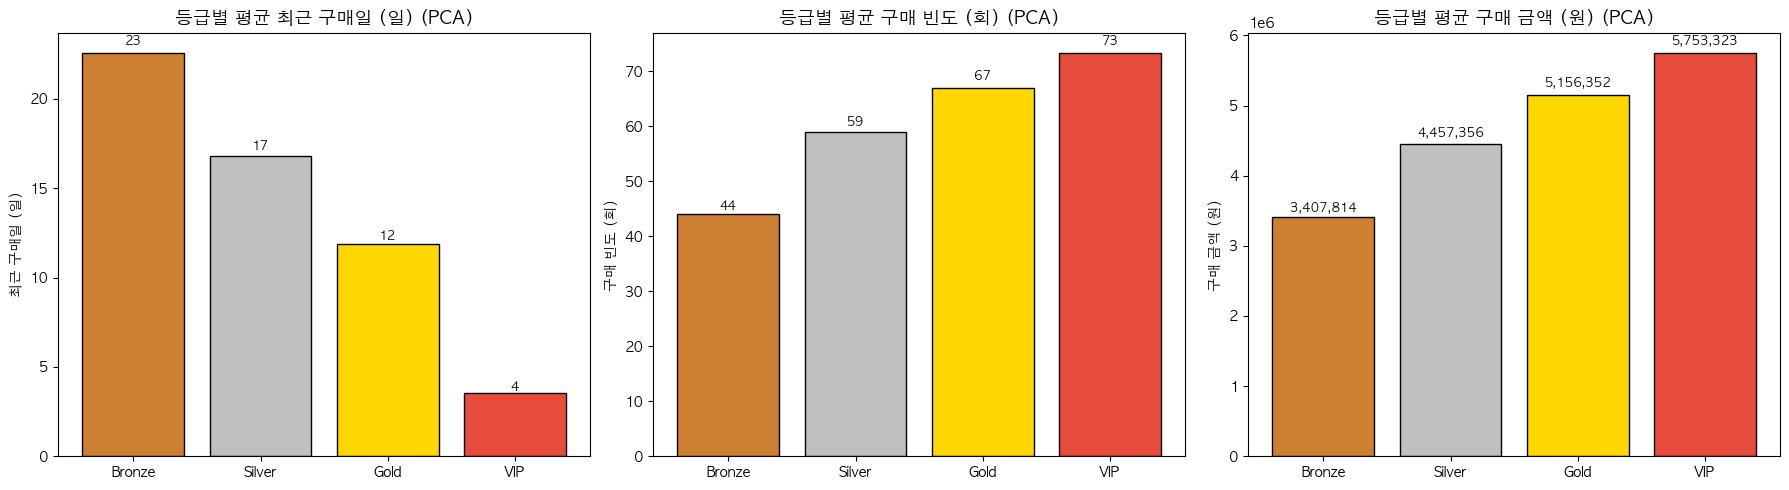

In [55]:
# =============================================
# Step 5-3: 시각화 - 등급별 R, F, M 평균 비교
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
grade_order_pca = ['Bronze', 'Silver', 'Gold', 'VIP']
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e74c3c']

metrics = [('Recency', '최근 구매일 (일)'), 
           ('Frequency', '구매 빈도 (회)'), 
           ('Monetary', '구매 금액 (원)')]

for ax, (col, ylabel) in zip(axes, metrics):
    means = rfm_pca.groupby('Grade', observed=True)[col].mean().reindex(grade_order_pca)
    ax.bar(grade_order_pca, means.values, color=colors, edgecolor='black')
    ax.set_title(f'등급별 평균 {ylabel} (PCA)', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    for i, v in enumerate(means.values):
        ax.text(i, v + v * 0.02, f'{v:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

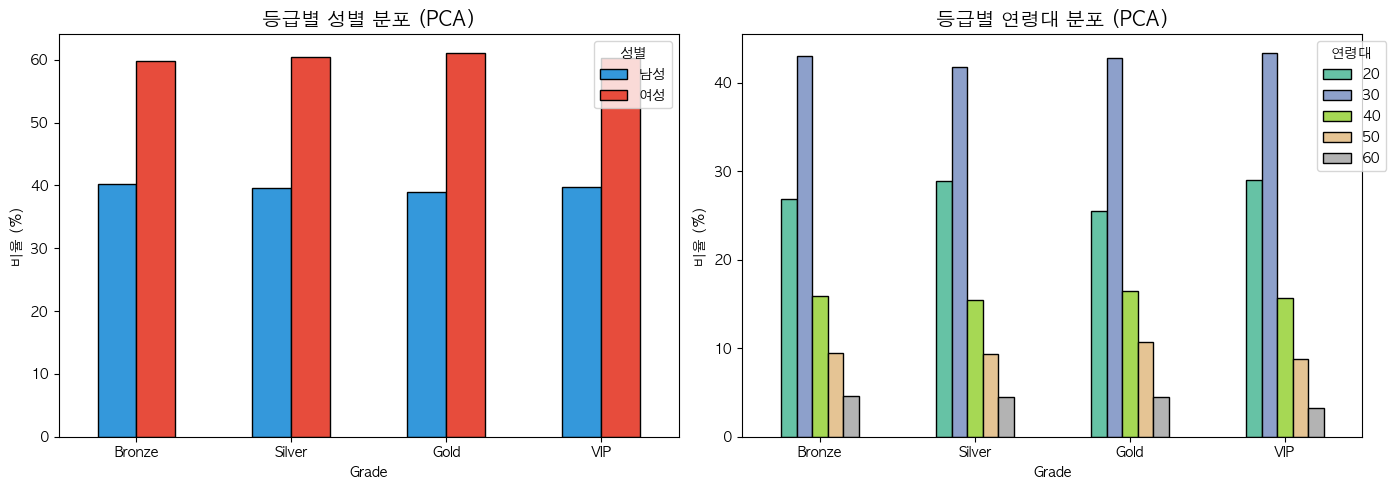

In [56]:
# =============================================
# Step 5-4: 시각화 - 등급별 인구통계 특성
# =============================================

customer_info_pca = df.groupby('idUser').agg(
    Gender=('Gender', 'first'),
    AgeGroup=('AgeGroup', 'first')
).reset_index()

rfm_pca_demo = rfm_pca.merge(customer_info_pca, on='idUser')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 등급별 성별 분포
ct_gender_pca = pd.crosstab(rfm_pca_demo['Grade'], rfm_pca_demo['Gender'], normalize='index') * 100
ct_gender_pca = ct_gender_pca.reindex(grade_order_pca)
ct_gender_pca.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('등급별 성별 분포 (PCA)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xticklabels(grade_order_pca, rotation=0)
axes[0].legend(title='성별')

# 등급별 연령대 분포
ct_age_pca = pd.crosstab(rfm_pca_demo['Grade'], rfm_pca_demo['AgeGroup'], normalize='index') * 100
ct_age_pca = ct_age_pca.reindex(grade_order_pca)
ct_age_pca.plot(kind='bar', ax=axes[1], edgecolor='black', cmap='Set2')
axes[1].set_title('등급별 연령대 분포 (PCA)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xticklabels(grade_order_pca, rotation=0)
axes[1].legend(title='연령대', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

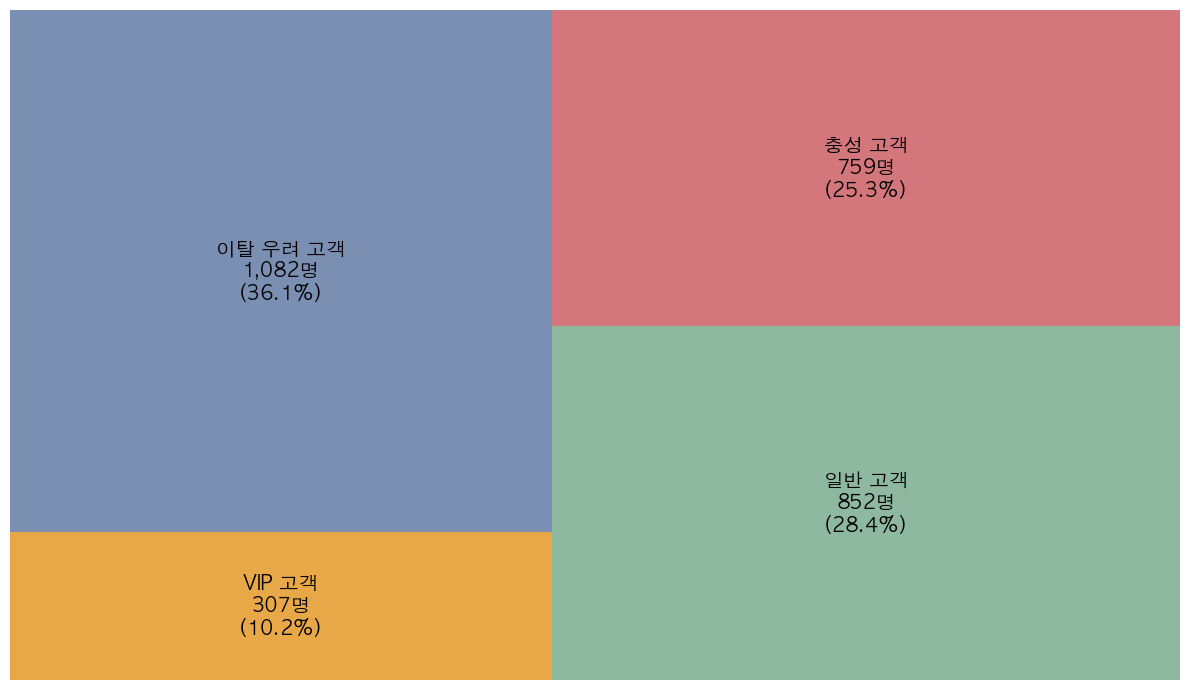

In [57]:
# =============================================
# Step 5-5: 시각화 - 트리맵 (등급별 고객 분포)
# =============================================
import squarify

grade_counts = rfm_pca['Grade'].value_counts()
grade_map = {'VIP': 'VIP 고객', 'Gold': '충성 고객', 'Silver': '일반 고객', 'Bronze': '이탈 우려 고객'}
color_map = {'VIP 고객': '#E8A848', '일반 고객': '#8FB8A0', '이탈 우려 고객': '#7B8FB2', '충성 고객': '#D4777C'}

total = grade_counts.sum()
labels = []
sizes = []
colors = []
for grade in ['VIP', 'Bronze', 'Silver', 'Gold']:
    name = grade_map[grade]
    cnt = grade_counts[grade]
    pct = cnt / total * 100
    labels.append(f'{name}\n{cnt:,}명\n({pct:.1f}%)')
    sizes.append(cnt)
    colors.append(color_map[name])

fig, ax = plt.subplots(figsize=(12, 7))
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=1.0,
              text_kwargs={'fontsize': 14, 'fontweight': 'bold'}, ax=ax)
ax.axis('off')
plt.tight_layout()
plt.show()

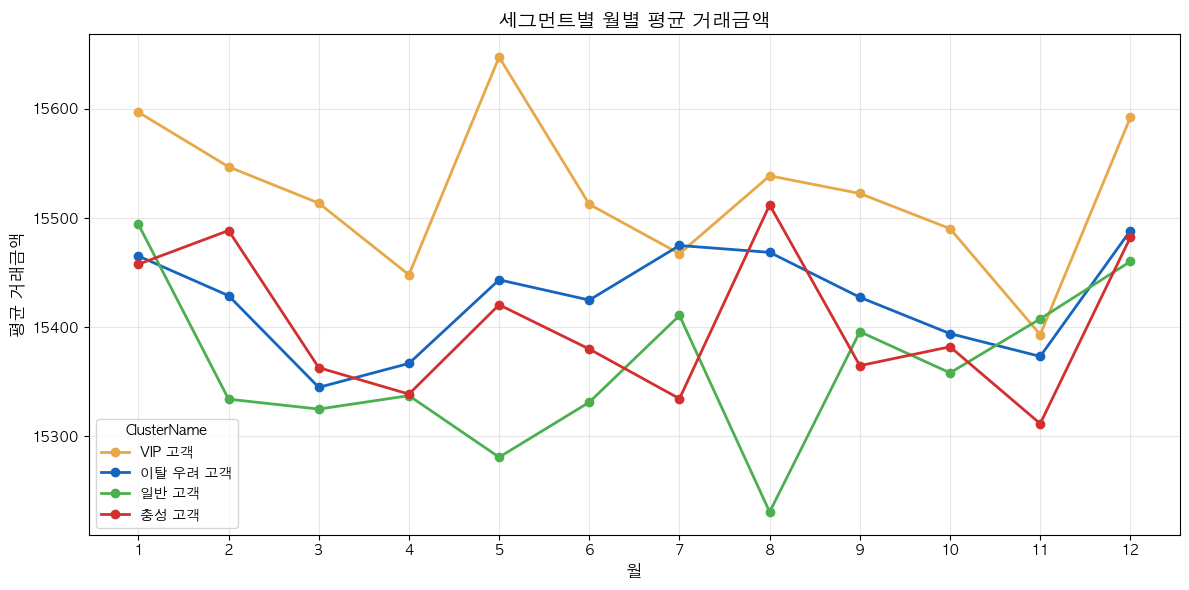

In [58]:
# =============================================
# Step 5-6: 시각화 - 세그먼트별 월별 평균 거래금액
# =============================================

grade_map = {'VIP': 'VIP 고객', 'Gold': '충성 고객', 'Silver': '일반 고객', 'Bronze': '이탈 우려 고객'}

# df와 rfm_pca를 merge하여 각 주문에 등급 부여
df_with_grade = df.merge(rfm_pca[['idUser', 'Grade']], on='idUser', how='inner')
df_with_grade['ClusterName'] = df_with_grade['Grade'].map(grade_map)
df_with_grade['Month'] = df_with_grade['OrderDT'].dt.month

# 세그먼트별 월별 평균 거래금액
monthly_avg = df_with_grade.groupby(['ClusterName', 'Month'])['Price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
cluster_colors = {'VIP 고객': '#E8A848', '이탈 우려 고객': '#1565C0', '일반 고객': '#4CAF50', '충성 고객': '#D32F2F'}

for name in ['VIP 고객', '이탈 우려 고객', '일반 고객', '충성 고객']:
    subset = monthly_avg[monthly_avg['ClusterName'] == name]
    ax.plot(subset['Month'], subset['Price'], marker='o', label=name, linewidth=2, color=cluster_colors[name])

ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('평균 거래금액', fontsize=12)
ax.set_title('세그먼트별 월별 평균 거래금액', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.legend(title='ClusterName')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

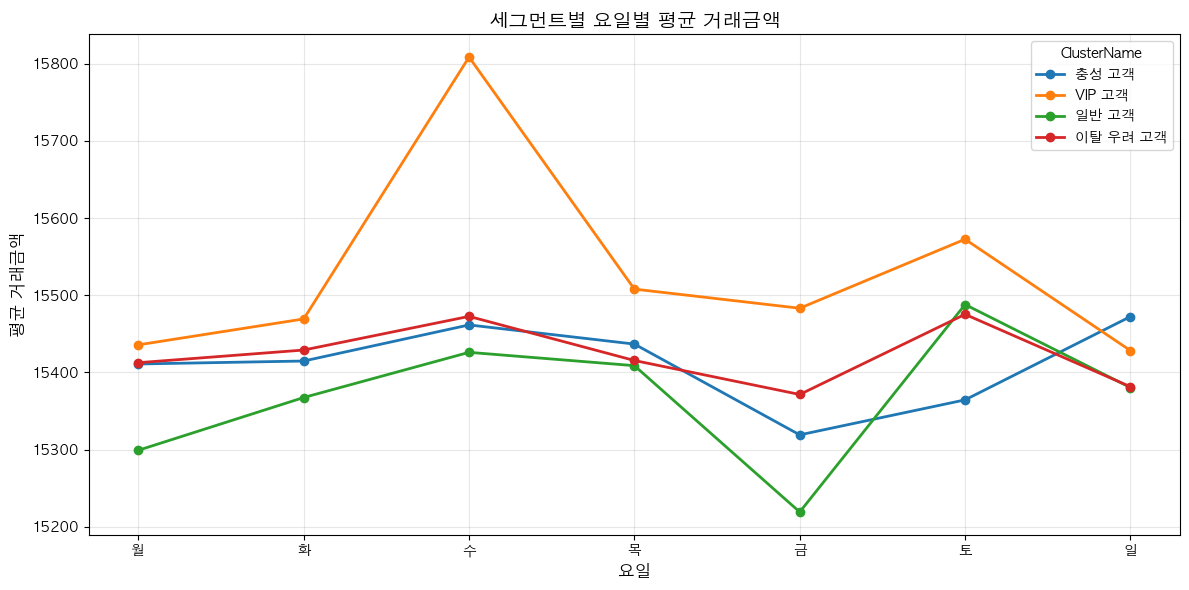

In [59]:
# =============================================
# Step 5-7: 시각화 - 세그먼트별 요일별 평균 거래금액
# =============================================

day_order = ['월', '화', '수', '목', '금', '토', '일']
day_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}

df_with_grade['DayOfWeek'] = df_with_grade['OrderDT'].dt.dayofweek.map(day_map)

# 세그먼트별 요일별 평균 거래금액
dow_avg = df_with_grade.groupby(['ClusterName', 'DayOfWeek'])['Price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

for name in ['충성 고객', 'VIP 고객', '일반 고객', '이탈 우려 고객']:
    subset = dow_avg[dow_avg['ClusterName'] == name]
    subset = subset.set_index('DayOfWeek').reindex(day_order).reset_index()
    ax.plot(subset['DayOfWeek'], subset['Price'], marker='o', label=name, linewidth=2)

ax.set_xlabel('요일', fontsize=12)
ax.set_ylabel('평균 거래금액', fontsize=12)
ax.set_title('세그먼트별 요일별 평균 거래금액', fontsize=14, fontweight='bold')
ax.legend(title='ClusterName')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: 결과 저장

In [60]:
# =============================================
# Step 6: 결과 저장 (PCA 가중치 버전)
# =============================================

rfm_pca.to_csv('../customer_rfm_pca.csv', index=False, encoding='cp949')
print(f"PCA 기반 RFM 결과 저장 완료: customer_rfm_pca.csv ({len(rfm_pca):,}명)")
print(f"\n=== 저장된 컬럼 ===")
print(rfm_pca.columns.tolist())
print(f"\n=== 최종 결과 미리보기 ===")
rfm_pca[['idUser', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 
         'composite_score', 'Grade']].head(10)

PCA 기반 RFM 결과 저장 완료: customer_rfm_pca.csv (3,000명)

=== 저장된 컬럼 ===
['idUser', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'R_percentile', 'F_percentile', 'M_percentile', 'composite_score', 'Grade']

=== 최종 결과 미리보기 ===


,idUser,Recency,Frequency,Monetary,R_score,F_score,M_score,composite_score,Grade
0,U10001,4,69,5414990,4,5,5,82.035707,VIP
1,U10002,25,53,3946750,2,2,2,28.946197,Bronze
2,U10003,8,53,4759100,3,2,4,50.879667,Silver
3,U10004,26,33,2498420,2,1,1,8.385254,Bronze
4,U10005,41,78,5563770,1,5,5,68.979681,Gold
5,U10006,4,70,5663150,4,5,5,85.049591,VIP
6,U10007,31,71,5688790,1,5,5,68.458002,Gold
7,U10008,5,65,5368790,4,4,5,75.426332,Gold
8,U10009,19,25,2054270,2,1,1,9.725641,Bronze
9,U10010,2,30,2089450,5,1,1,27.226545,Bronze


## Step 7: 점수 구분 기준표

=== 분위수 경계값 ===
Recency  (20/40/60/80%): [ 3.  7. 13. 26.]
Frequency (20/40/60/80%): [46. 56. 62. 68.]
Monetary  (20/40/60/80%): [3568666. 4213840. 4696480. 5242442.]


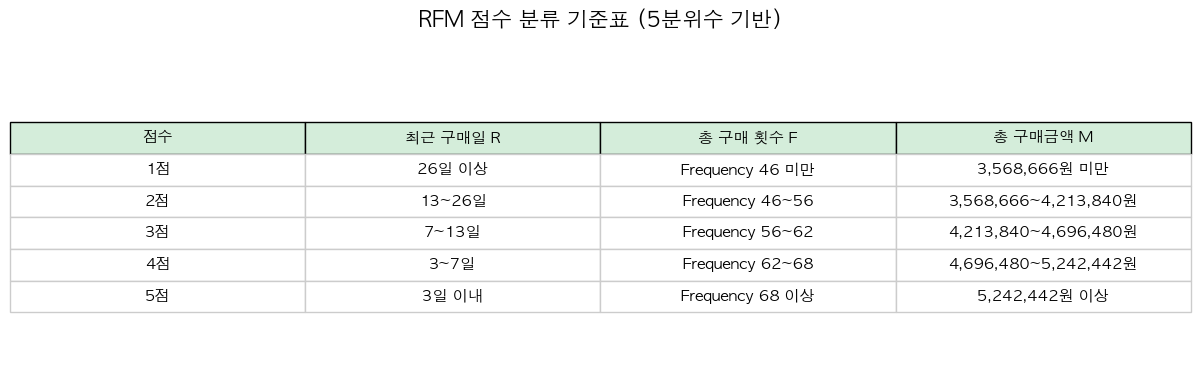

In [61]:
# =============================================
# RFM 점수 분류 기준표
# =============================================

# 실제 데이터 기반 분위수 경계값 확인
r_quantiles = rfm_pca['Recency'].quantile([0.2, 0.4, 0.6, 0.8]).values
f_quantiles = rfm_pca['Frequency'].quantile([0.2, 0.4, 0.6, 0.8]).values
m_quantiles = rfm_pca['Monetary'].quantile([0.2, 0.4, 0.6, 0.8]).values

print("=== 분위수 경계값 ===")
print(f"Recency  (20/40/60/80%): {r_quantiles}")
print(f"Frequency (20/40/60/80%): {f_quantiles}")
print(f"Monetary  (20/40/60/80%): {m_quantiles}")

# 점수 분류 기준표 시각화
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# 테이블 데이터
col_labels = ['점수', '최근 구매일 R', '총 구매 횟수 F', '총 구매금액 M']
table_data = [
    ['1점', f'{r_quantiles[3]:.0f}일 이상', f'Frequency {f_quantiles[0]:.0f} 미만', f'{m_quantiles[0]:,.0f}원 미만'],
    ['2점', f'{r_quantiles[2]:.0f}~{r_quantiles[3]:.0f}일', f'Frequency {f_quantiles[0]:.0f}~{f_quantiles[1]:.0f}', f'{m_quantiles[0]:,.0f}~{m_quantiles[1]:,.0f}원'],
    ['3점', f'{r_quantiles[1]:.0f}~{r_quantiles[2]:.0f}일', f'Frequency {f_quantiles[1]:.0f}~{f_quantiles[2]:.0f}', f'{m_quantiles[1]:,.0f}~{m_quantiles[2]:,.0f}원'],
    ['4점', f'{r_quantiles[0]:.0f}~{r_quantiles[1]:.0f}일', f'Frequency {f_quantiles[2]:.0f}~{f_quantiles[3]:.0f}', f'{m_quantiles[2]:,.0f}~{m_quantiles[3]:,.0f}원'],
    ['5점', f'{r_quantiles[0]:.0f}일 이내', f'Frequency {f_quantiles[3]:.0f} 이상', f'{m_quantiles[3]:,.0f}원 이상'],
]

table = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# 헤더 스타일
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#d4edda')
    table[0, j].set_text_props(fontweight='bold')

# 셀 스타일
for i in range(1, len(table_data) + 1):
    for j in range(len(col_labels)):
        table[i, j].set_facecolor('#ffffff')
        table[i, j].set_edgecolor('#cccccc')

ax.set_title('RFM 점수 분류 기준표 (5분위수 기반)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()